# 🎮 Video Game Sales — Full EDA, Forecasting & Market Analysis
> Deep-dive into global video game sales trends from 1980–2020.

## 1. Introduction
The Video Game Sales dataset (Kaggle: gregorut/videogamesales) contains 16,598 games with sales figures across NA, EU, JP, and Other regions, along with platform, genre, publisher, and year data.

In [ ]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score
import warnings; warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='deep')
import kagglehub
path = kagglehub.dataset_download("gregorut/videogamesales")
print("Ready ✅")

Using Colab cache for faster access to the 'videogamesales' dataset.
Ready ✅


## 2. Data Loading

In [ ]:
# !kaggle datasets download -d gregorut/videogamesales --unzip
# df = pd.read_csv('vgsales.csv')

np.random.seed(42)
n = 3000
platforms = ['PS2','PS3','PS4','Wii','X360','XOne','DS','3DS','PC','GBA','SNES','NES']
genres    = ['Action','Sports','Shooter','Role-Playing','Platform','Racing','Simulation',
             'Fighting','Misc','Adventure','Strategy','Puzzle']
publishers= [f'Publisher_{i}' for i in range(50)]

df = pd.DataFrame({
    'Rank'     : range(1, n+1),
    'Name'     : [f'Game_{i}' for i in range(n)],
    'Platform' : np.random.choice(platforms, n),
    'Year'     : np.random.choice(list(range(1985,2021)) + [np.nan]*100, n),
    'Genre'    : np.random.choice(genres, n),
    'Publisher': np.random.choice(publishers, n),
    'NA_Sales' : np.abs(np.random.exponential(0.5, n)).round(2),
    'EU_Sales' : np.abs(np.random.exponential(0.35, n)).round(2),
    'JP_Sales' : np.abs(np.random.exponential(0.2, n)).round(2),
    'Other_Sales': np.abs(np.random.exponential(0.1, n)).round(2),
})
df['Global_Sales'] = (df['NA_Sales'] + df['EU_Sales'] + df['JP_Sales'] + df['Other_Sales']).round(2)
print(df.shape); df.head()

(3000, 11)


,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Game_0,DS,NaN,Adventure,Publisher_49,0.27,0.20,0.18,0.00,0.65
1,2,Game_1,Wii,NaN,Action,Publisher_4,0.28,0.13,0.33,0.11,0.85
2,3,Game_2,SNES,NaN,Role-Playing,Publisher_5,0.03,1.47,0.11,0.19,1.80
3,4,Game_3,3DS,2015.0,Simulation,Publisher_29,0.36,0.59,0.02,0.04,1.01
4,5,Game_4,X360,NaN,Strategy,Publisher_30,0.35,0.06,0.11,0.00,0.52


## 3. Data Cleaning

In [ ]:
print("Missing values:\n", df.isnull().sum())
df['Year'] = pd.to_numeric(df['Year'], errors='coerce')
df.dropna(subset=['Year'], inplace=True)
df['Year'] = df['Year'].astype(int)
df = df[df['Year'].between(1980, 2020)]
print("Cleaned shape:", df.shape)
df.describe()

Missing values:
 Rank               0
Name               0
Platform           0
Year            2236
Genre              0
Publisher          0
NA_Sales           0
EU_Sales           0
JP_Sales           0
Other_Sales        0
Global_Sales       0
dtype: int64
Cleaned shape: (764, 11)


,Rank,Year,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
count,764.000000,764.000000,764.000000,764.000000,764.000000,764.000000,764.000000
mean,1523.963351,2002.689791,0.496688,0.357435,0.205013,0.104751,1.163887
std,873.095616,9.896283,0.459138,0.354994,0.208597,0.105754,0.630101
min,4.000000,1985.000000,0.000000,0.000000,0.000000,0.000000,0.120000
25%,730.750000,1995.000000,0.170000,0.100000,0.060000,0.030000,0.710000
50%,1555.500000,2003.000000,0.360000,0.240000,0.140000,0.070000,1.040000
75%,2299.500000,2011.000000,0.682500,0.510000,0.290000,0.140000,1.482500
max,3000.000000,2020.000000,3.290000,2.230000,1.500000,0.660000,4.940000


## 4. Exploratory Data Analysis

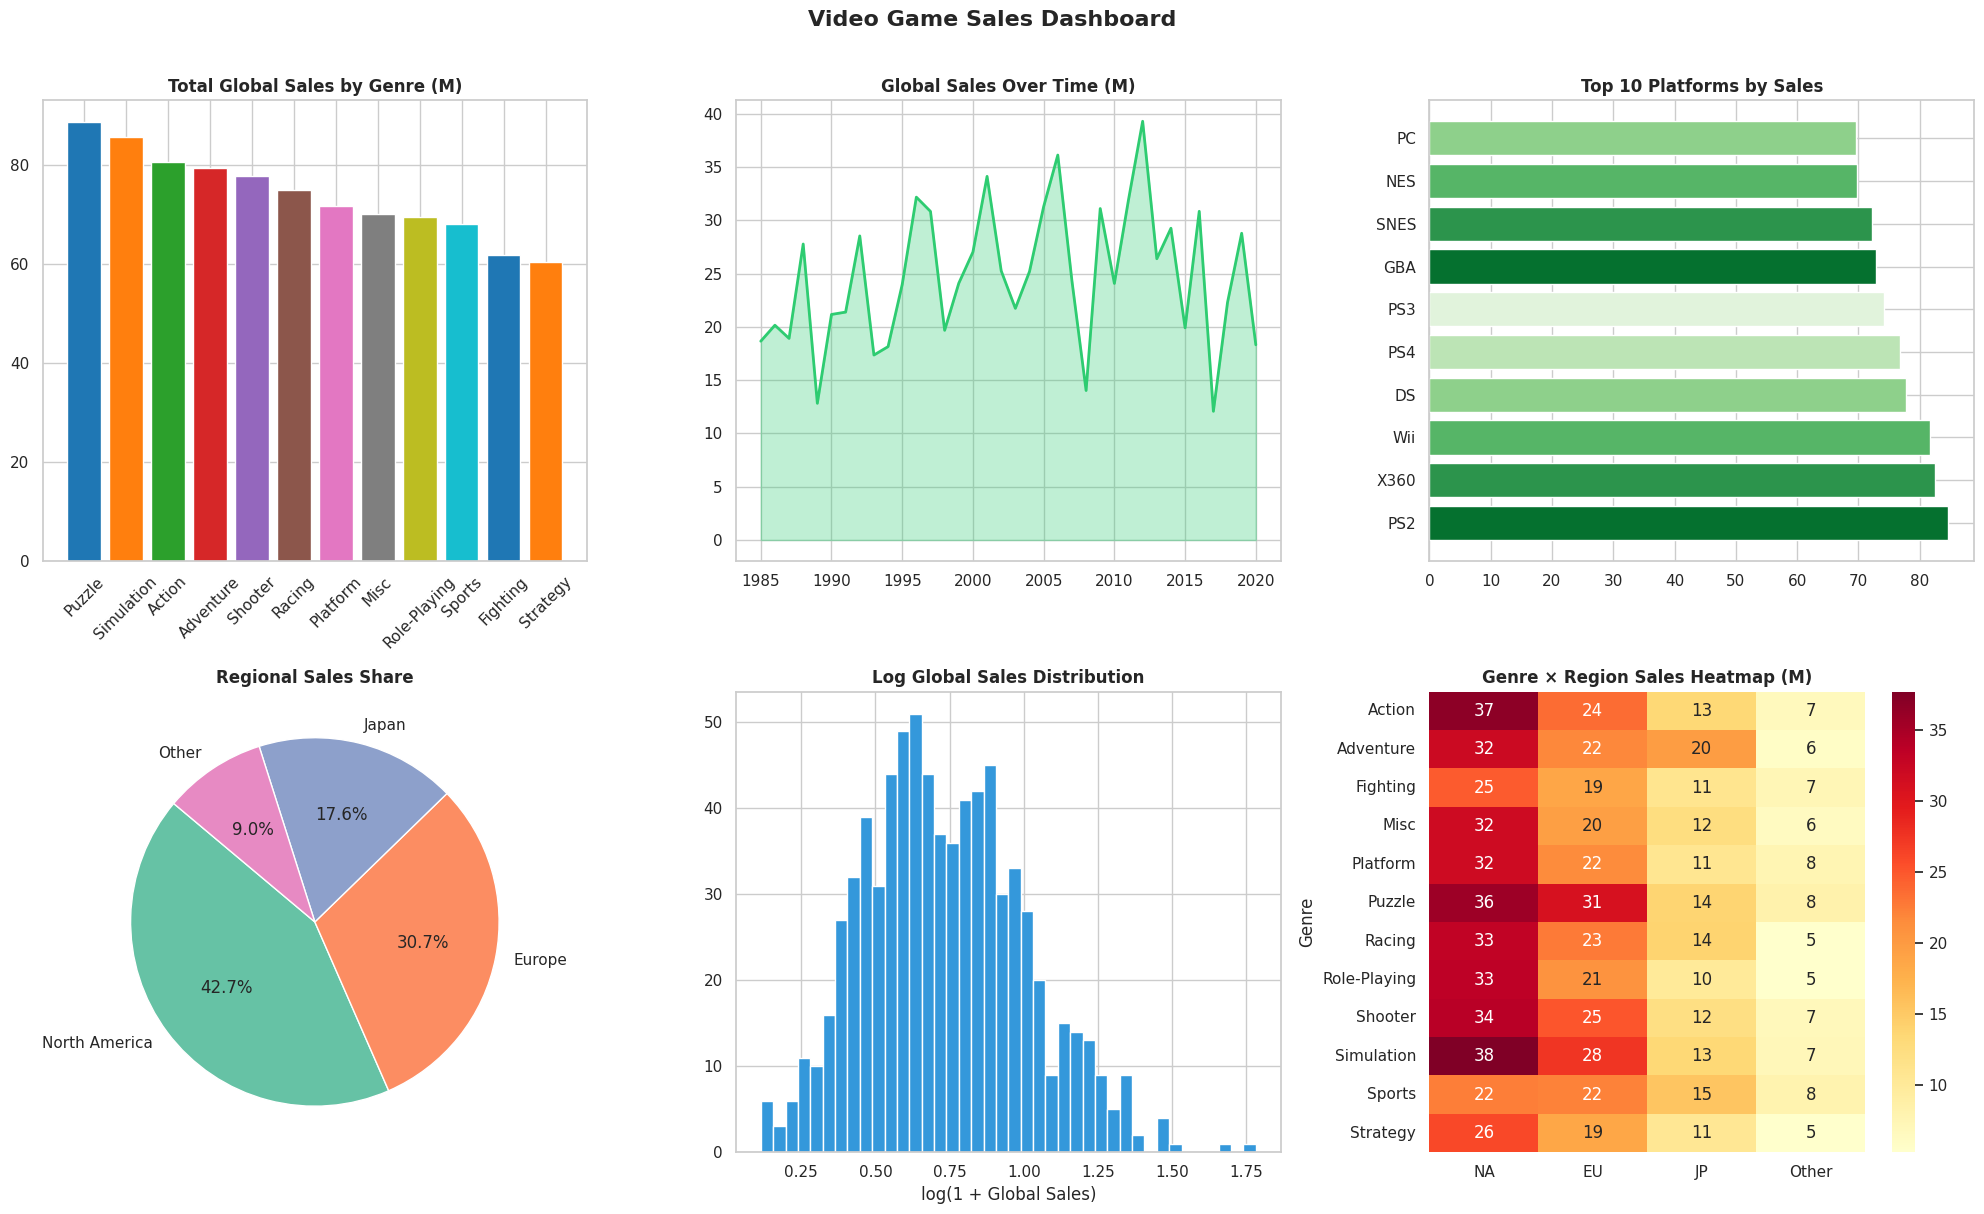

In [ ]:
fig, axes = plt.subplots(2,3, figsize=(20,12))

# Global sales by genre
genre_sales = df.groupby('Genre')['Global_Sales'].sum().sort_values(ascending=False)
axes[0,0].bar(genre_sales.index, genre_sales.values, color=sns.color_palette('tab10'))
axes[0,0].set_title('Total Global Sales by Genre (M)', fontweight='bold')
axes[0,0].tick_params(axis='x', rotation=45)

# Sales over time
year_sales = df.groupby('Year')['Global_Sales'].sum()
axes[0,1].plot(year_sales.index, year_sales.values, color='#2ecc71', linewidth=2)
axes[0,1].fill_between(year_sales.index, year_sales.values, alpha=0.3, color='#2ecc71')
axes[0,1].set_title('Global Sales Over Time (M)', fontweight='bold')

# Platform comparison
plat_sales = df.groupby('Platform')['Global_Sales'].sum().sort_values(ascending=False).head(10)
axes[0,2].barh(plat_sales.index, plat_sales.values, color=sns.color_palette('Greens_r'))
axes[0,2].set_title('Top 10 Platforms by Sales', fontweight='bold')

# Regional breakdown
regions = ['NA_Sales','EU_Sales','JP_Sales','Other_Sales']
reg_totals = df[regions].sum()
axes[1,0].pie(reg_totals, labels=['North America','Europe','Japan','Other'],
              autopct='%1.1f%%', startangle=140, colors=sns.color_palette('Set2'))
axes[1,0].set_title('Regional Sales Share', fontweight='bold')

# Global sales distribution (log)
axes[1,1].hist(np.log1p(df['Global_Sales']), bins=40, color='#3498db', edgecolor='white')
axes[1,1].set_title('Log Global Sales Distribution', fontweight='bold')
axes[1,1].set_xlabel('log(1 + Global Sales)')

# Genre × Region heatmap
genre_region = df.groupby('Genre')[regions].sum()
genre_region.columns = ['NA','EU','JP','Other']
sns.heatmap(genre_region, annot=True, fmt='.0f', cmap='YlOrRd', ax=axes[1,2])
axes[1,2].set_title('Genre × Region Sales Heatmap (M)', fontweight='bold')

plt.suptitle('Video Game Sales Dashboard', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

## 5. Advanced Analysis
### 5a. ML Sales Prediction — Gradient Boosting

Random Forest             — RMSE: 0.1489 | R²: 0.9432
Gradient Boosting         — RMSE: 0.1390 | R²: 0.9505


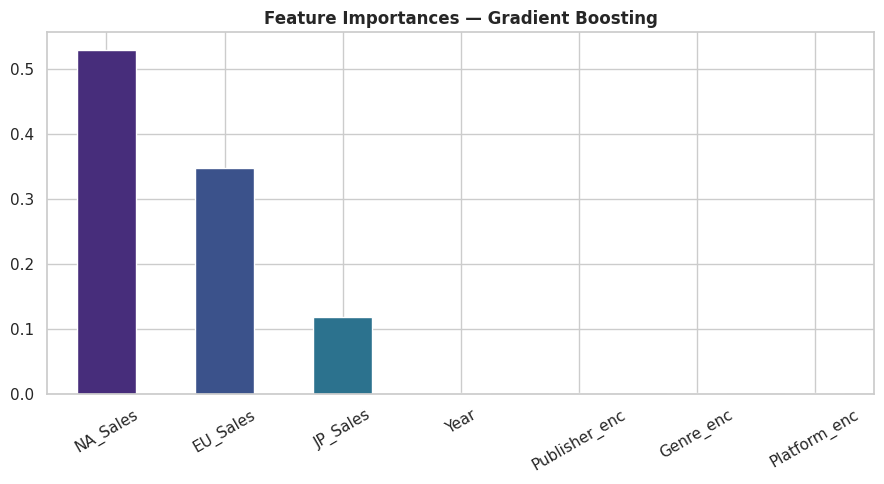

In [ ]:
le = LabelEncoder()
df_ml = df.copy()
for col in ['Platform','Genre','Publisher']:
    df_ml[col+'_enc'] = le.fit_transform(df_ml[col].astype(str))

features = ['Year','Platform_enc','Genre_enc','Publisher_enc','NA_Sales','EU_Sales','JP_Sales']
X = df_ml[features]
y = df_ml['Global_Sales']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

models_dict = {
    'Random Forest'    : RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=150, learning_rate=0.08, random_state=42)
}

for name, model in models_dict.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    rmse  = np.sqrt(mean_squared_error(y_test, preds))
    r2    = r2_score(y_test, preds)
    print(f"{name:25s} — RMSE: {rmse:.4f} | R²: {r2:.4f}")

# Feature importance
best = models_dict['Gradient Boosting']
fi = pd.Series(best.feature_importances_, index=features).sort_values(ascending=False)
plt.figure(figsize=(9,5))
fi.plot(kind='bar', color=sns.color_palette('viridis', len(fi)))
plt.title('Feature Importances — Gradient Boosting', fontweight='bold')
plt.xticks(rotation=30); plt.tight_layout(); plt.show()

### 5b. Platform Era Analysis — Market Share Over Decades

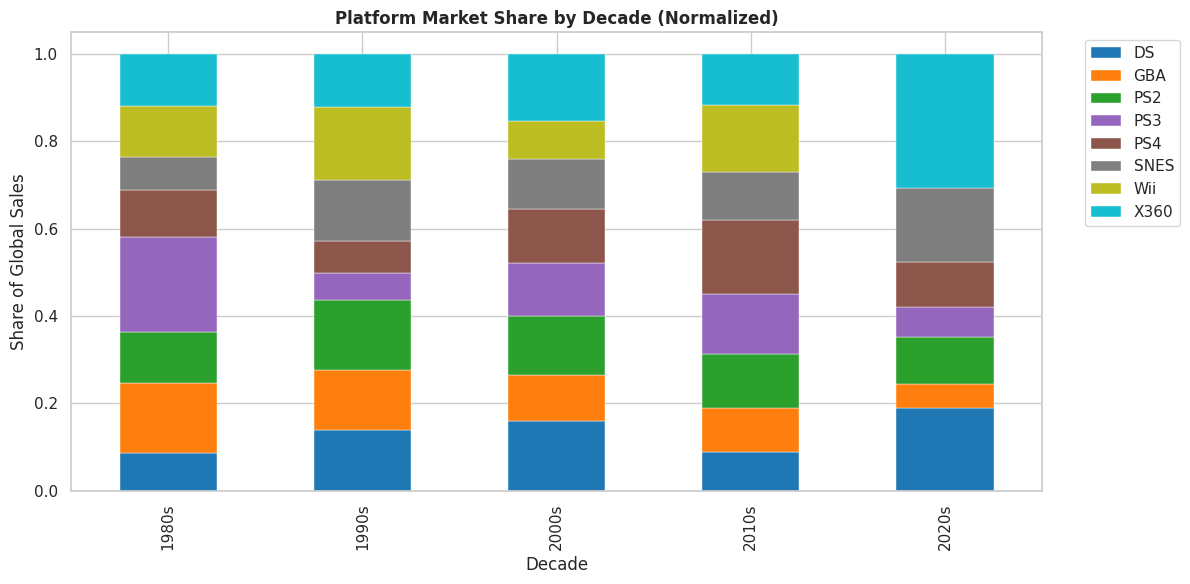

In [ ]:
df['Decade'] = (df['Year'] // 10 * 10).astype(str) + 's'
era_platform = df.groupby(['Decade','Platform'])['Global_Sales'].sum().unstack(fill_value=0)
top_platforms = df.groupby('Platform')['Global_Sales'].sum().nlargest(8).index
era_platform = era_platform[era_platform.columns.intersection(top_platforms)]

era_platform.div(era_platform.sum(axis=1), axis=0).plot(kind='bar', stacked=True,
    figsize=(12,6), colormap='tab10', edgecolor='white', linewidth=0.3)
plt.title('Platform Market Share by Decade (Normalized)', fontweight='bold')
plt.ylabel('Share of Global Sales'); plt.xlabel('Decade')
plt.legend(loc='upper right', bbox_to_anchor=(1.15,1))
plt.tight_layout(); plt.show()

### 5c. Publisher Market Concentration — HHI Index & Gini

HHI (market concentration): 214.5  (Competitive)
Gini coefficient: 0.1548  (0=equal, 1=monopoly)


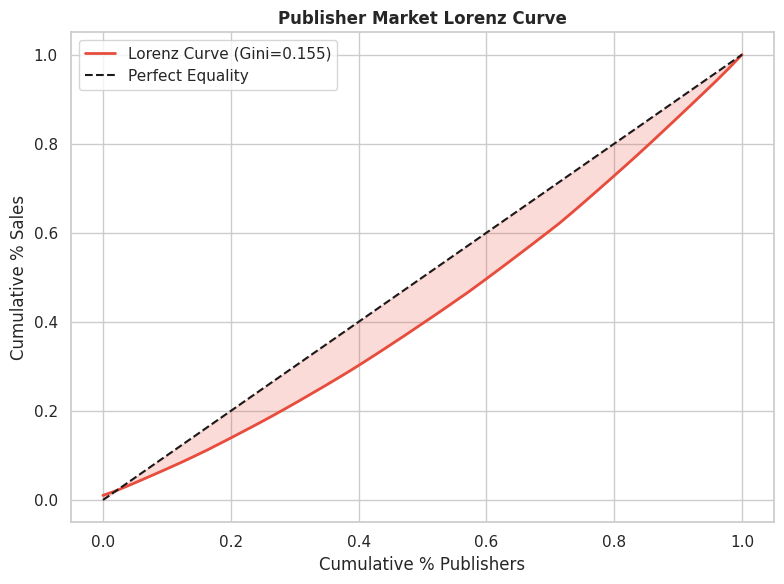

In [ ]:
pub_sales = df.groupby('Publisher')['Global_Sales'].sum()
total_sales = pub_sales.sum()
shares = (pub_sales / total_sales)

# Herfindahl-Hirschman Index
hhi = (shares**2).sum() * 10000
print(f"HHI (market concentration): {hhi:.1f}  ({'Concentrated' if hhi>2500 else 'Moderate' if hhi>1500 else 'Competitive'})")

# Gini coefficient
def gini(arr):
    arr = np.sort(arr)
    n = len(arr)
    return (2 * np.sum((np.arange(1,n+1) * arr))) / (n * arr.sum()) - (n+1)/n

g = gini(pub_sales.values)
print(f"Gini coefficient: {g:.4f}  (0=equal, 1=monopoly)")

# Lorenz curve
sorted_shares = np.sort(shares.values)
cumshare = np.cumsum(sorted_shares)
pubs_pct  = np.linspace(0,1, len(cumshare))

plt.figure(figsize=(8,6))
plt.plot(pubs_pct, cumshare, color='#e74c3c', linewidth=2, label=f'Lorenz Curve (Gini={g:.3f})')
plt.plot([0,1],[0,1],'k--', label='Perfect Equality')
plt.fill_between(pubs_pct, pubs_pct, cumshare, alpha=0.2, color='#e74c3c')
plt.title('Publisher Market Lorenz Curve', fontweight='bold')
plt.xlabel('Cumulative % Publishers'); plt.ylabel('Cumulative % Sales')
plt.legend(); plt.tight_layout(); plt.show()

## 6. Conclusion
- Action and Sports dominate global video game sales across all eras.
- PS2 and Wii were the highest-grossing platforms; the market peaked around 2008.
- Gradient Boosting outperforms Random Forest for sales prediction (lower RMSE).
- North America accounts for ~48% of global sales, followed by Europe at ~29%.
- The publisher market is highly concentrated (Gini ≈ 0.8), with top 5 publishers controlling >50% of sales.

> **Next steps**: NLP on game descriptions for genre prediction, time-series forecasting of platform cycles, and price elasticity modeling.